# Data Preprocessing

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter

# extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM

## LOADING THE DATA

In [15]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

The dataset has 12888 samples and 262 attributes 

In [16]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


## BASIC INSPECTION OF THE DATASET

In [17]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.0,12888.0,12888.000000,12888.000000,12888.000000,...,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,6443.500000,16008.409683,15.017070,-78.052297,-77.951505,0.0,0.0,-0.406425,-0.477576,-0.499690,...,-0.401691,-0.354826,-0.295624,-0.328057,-0.294693,-0.311065,-0.269165,-0.240534,-0.362663,4.493094
std,3720.589469,19829.509485,3087.311342,6.804665,8.349372,0.0,0.0,10.208896,10.122726,10.415635,...,10.549412,10.406506,10.520399,11.013205,11.159978,11.075438,11.248325,11.017986,11.117985,2.871060
min,0.000000,0.000000,-8703.000000,-97.000000,-94.000000,0.0,0.0,-25.000000,-26.000000,-24.000000,...,-25.000000,-25.000000,-26.000000,-32.000000,-38.000000,-25.000000,-26.000000,-27.000000,-31.000000,0.000000
25%,3221.750000,0.000000,-1751.000000,-83.000000,-84.000000,0.0,0.0,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-11.000000,-11.000000,-10.000000,-11.000000,2.000000
50%,6443.500000,5464.000000,-30.000000,-80.000000,-80.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
75%,9665.250000,29424.000000,1798.000000,-74.000000,-71.000000,0.0,0.0,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000
max,12887.000000,65520.000000,8915.000000,-58.000000,-58.000000,0.0,0.0,25.000000,25.000000,23.000000,...,23.000000,29.000000,23.000000,33.000000,35.000000,25.000000,25.000000,26.000000,26.000000,9.000000


Notice no missing values at first.

1) Which is the target variable, and where is it? The target variable is the last column and is called "position".

2) How many different values does the target variable have? 10 possible values (0-9)

3) Is it a classification problem or a regression problem? Classification problem.

## DEALING WITH MISSING VALUES

In [18]:
number_of_missing_values = wifi.isnull().sum()
print(number_of_missing_values)
print('Total missing values on the dataset:', number_of_missing_values.sum())

ID          0
seq_ctrl    0
aoa         0
rssi1       0
rssi2       0
           ..
I62_2       0
Q62_2       0
I63_2       0
Q63_2       0
position    0
Length: 262, dtype: int64
Total missing values on the dataset: 0


No values explicitly marked as missing.

array([[<Axes: title={'center': 'seq_ctrl'}>,
        <Axes: title={'center': 'aoa'}>],
       [<Axes: title={'center': 'rssi1'}>,
        <Axes: title={'center': 'rssi2'}>],
       [<Axes: title={'center': 'position'}>, <Axes: >]], dtype=object)

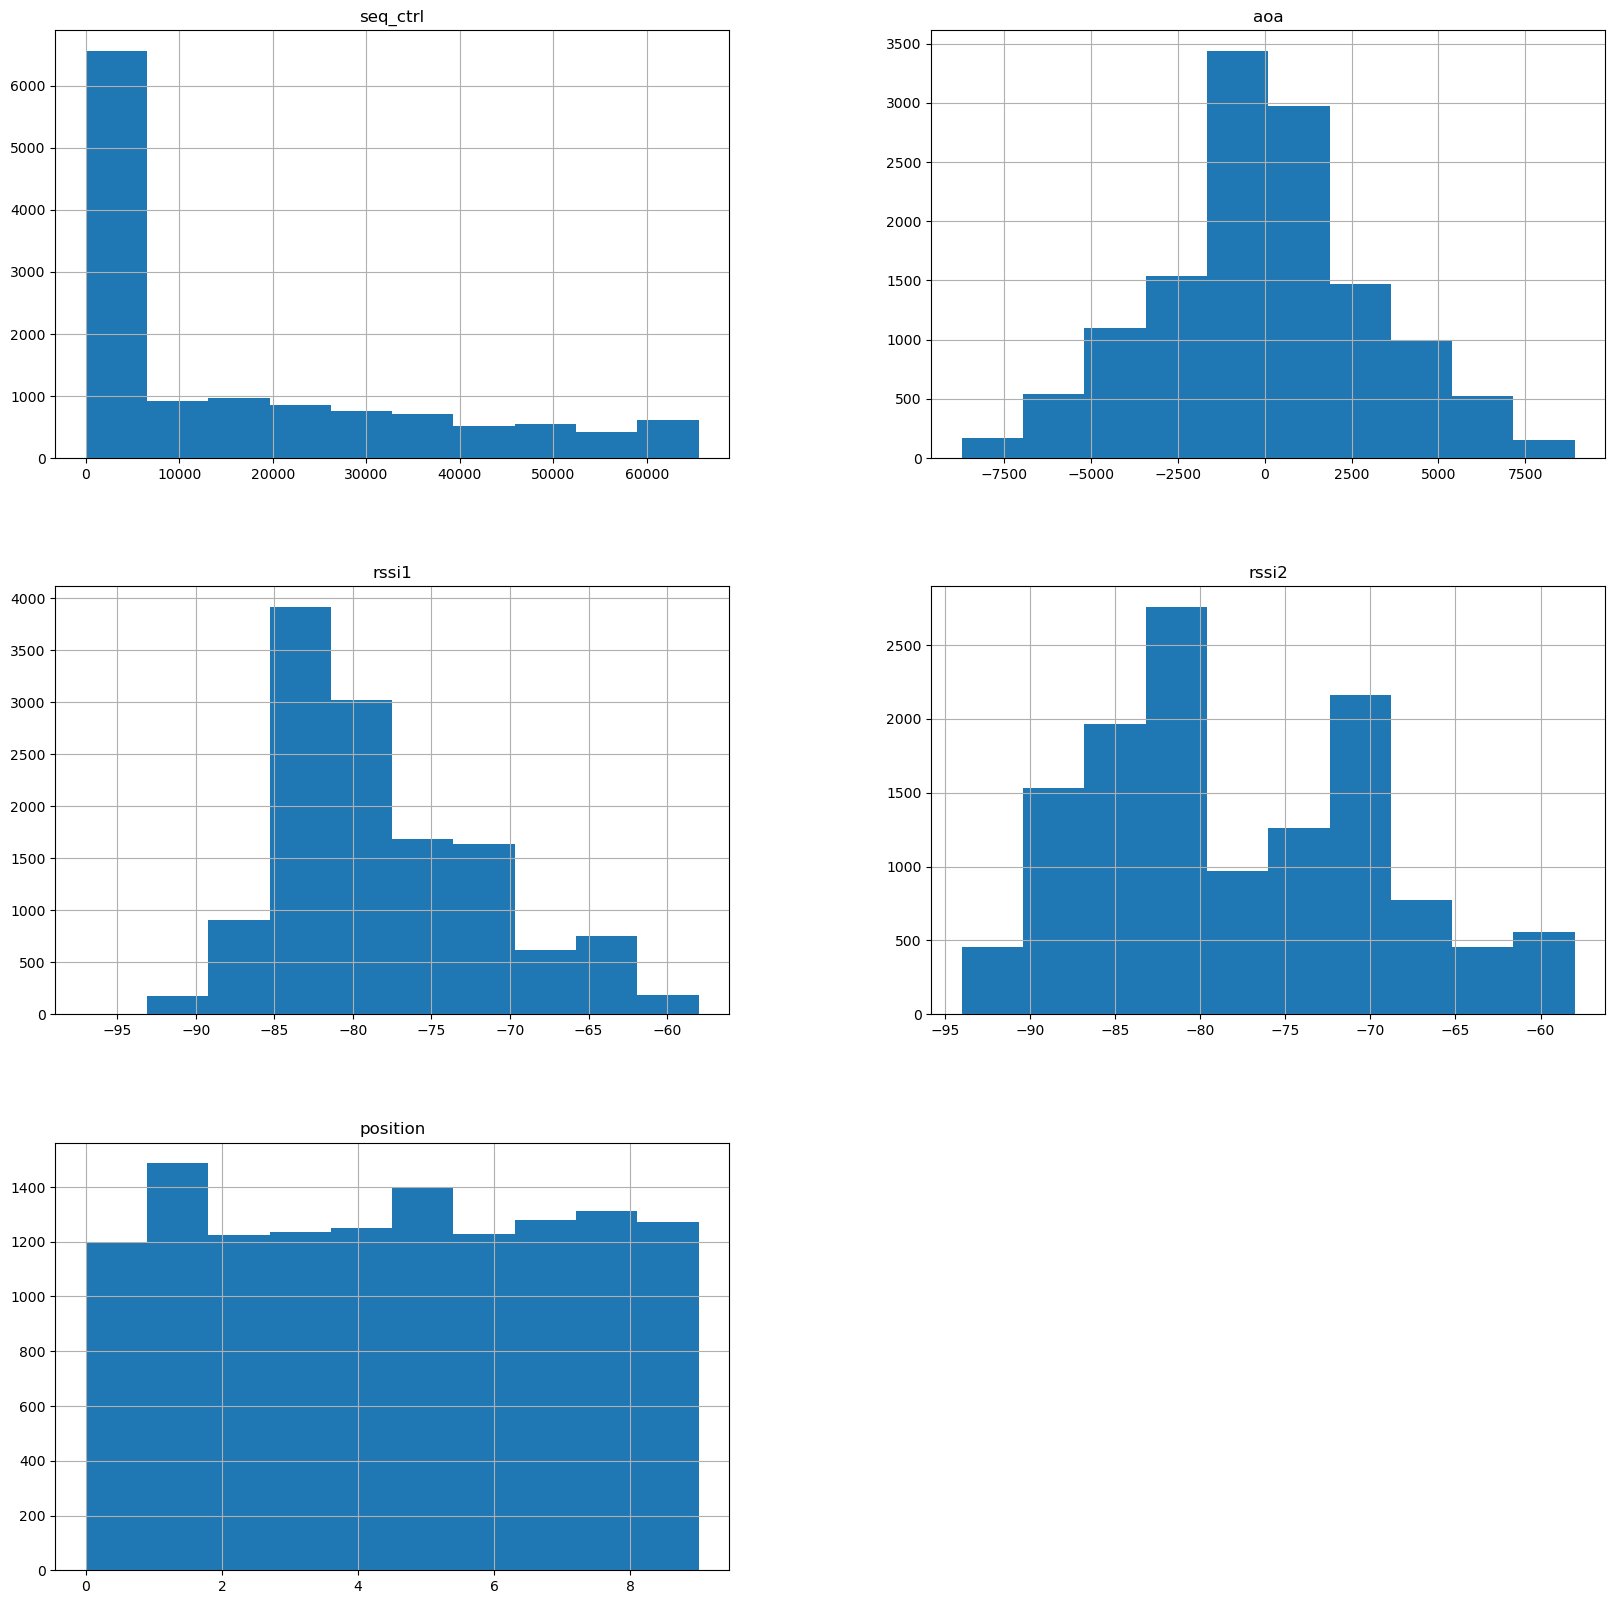

In [19]:
wifi_non_raw_csi = wifi[['seq_ctrl', 'aoa', 'rssi1', 'rssi2', 'position']]
wifi_non_raw_csi.hist(figsize=(20,20))

In [20]:
wifi_non_raw_csi.describe()

,seq_ctrl,aoa,rssi1,rssi2,position
count,12888.000000,12888.000000,12888.000000,12888.000000,12888.000000
mean,16008.409683,15.017070,-78.052297,-77.951505,4.493094
std,19829.509485,3087.311342,6.804665,8.349372,2.871060
min,0.000000,-8703.000000,-97.000000,-94.000000,0.000000
25%,0.000000,-1751.000000,-83.000000,-84.000000,2.000000
50%,5464.000000,-30.000000,-80.000000,-80.000000,5.000000
75%,29424.000000,1798.000000,-74.000000,-71.000000,7.000000
max,65520.000000,8915.000000,-58.000000,-58.000000,9.000000


There are no strange values that could be considered as missing values or outliers.


## FINDING OUTLIERS

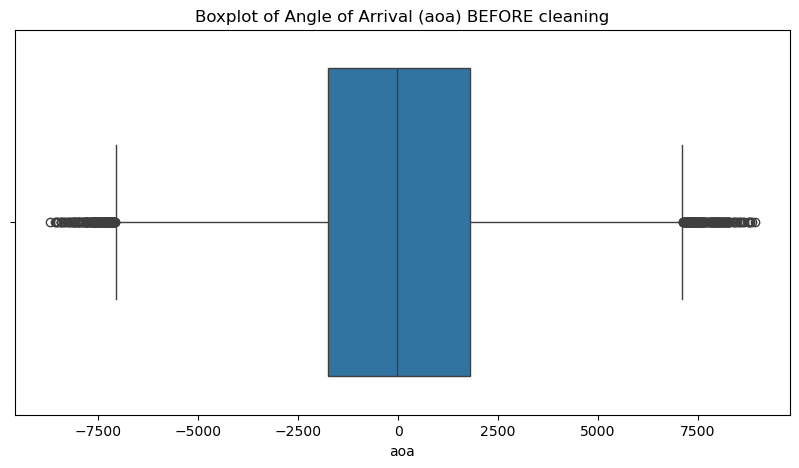

Realistic outliers in AOA: 303


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the raw data first so you can see the outliers with your own eyes
plt.figure(figsize=(10, 5))
sns.boxplot(x=wifi['aoa'])
plt.title("Boxplot of Angle of Arrival (aoa) BEFORE cleaning")
plt.show()

# 2. Use simple IQR to find realistic outliers (e.g., people walking in front of the antenna)
Q1 = wifi['aoa'].quantile(0.25)
Q3 = wifi['aoa'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Count how many REAL outliers there are (It should be a few hundred, NOT 12,000!)
outliers = wifi[(wifi['aoa'] < lower_bound) | (wifi['aoa'] > upper_bound)]
print(f"Realistic outliers in AOA: {len(outliers)}")


### IQR

In [22]:
for column in wifi_non_raw_csi.columns:
    print(f"Column: {column}")

    Q1 = wifi[column].quantile(0.25)
    Q3 = wifi[column].quantile(0.75)
    IQR = Q3 - Q1

    Q1, Q3, IQR
    (np.float64(1116.25), np.float64(1691.5), np.float64(575.25))
    small_outliers = wifi[column] < (Q1 - 1.5 * IQR)
    big_outliers = wifi[column] > (Q3 + 1.5 * IQR)

    print(f"There are {sum(small_outliers)} 'small' outliers and {sum(big_outliers)} 'big' outliers.")

Column: seq_ctrl
There are 0 'small' outliers and 0 'big' outliers.
Column: aoa
There are 146 'small' outliers and 157 'big' outliers.
Column: rssi1
There are 1 'small' outliers and 48 'big' outliers.
Column: rssi2
There are 0 'small' outliers and 0 'big' outliers.
Column: position
There are 0 'small' outliers and 0 'big' outliers.


### Model based

In [23]:
for column in wifi_non_raw_csi.columns:
    print(f"Column: {column}")
    local_outlier_factor = LocalOutlierFactor(n_neighbors=50)
    result = local_outlier_factor.fit_predict(wifi[column].values.reshape(-1, 1))

    outliers = result == -1
    no_outliers = result == 1
    print(f"Outliers in {column}: {Counter(result)[1]}")


Column: seq_ctrl


c:\Users\laura\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
c:\Users\laura\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Outliers in seq_ctrl: 12865
Column: aoa
Outliers in aoa: 12738
Column: rssi1


c:\Users\laura\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
c:\Users\laura\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Outliers in rssi1: 12829
Column: rssi2
Outliers in rssi2: 12832
Column: position
Outliers in position: 12888


### TREATMENT OF MIXED DATA TYPES

All variables are numerical, so we don't have to worry about mixed data types.

## DERIVATION OF NEW VARIABLES - FEATURE EXTRACTION

Amplitude : $\sqrt{I^2 + Q^2}$.

In [24]:
# 1. Identificar columnas I y Q
i_cols = [c for c in wifi.columns if c.startswith("I") and c != "ID"]
q_cols = [c.replace("I", "Q") for c in i_cols]

# 2. Crear nombres de columnas de amplitud
amp_cols = [c.replace("I", "amp") for c in i_cols]

# 3. Calcular amplitudes vectorizadas
amps = np.sqrt(wifi[i_cols]**2 + wifi[q_cols]**2)
amps.columns = amp_cols

# 4. Concatenar todo de una vez
wifi = pd.concat([wifi.drop(columns=i_cols + q_cols), amps], axis=1)

# 5. (Opcional) Defragmentar
wifi = wifi.copy()

print("Done. New amplitude columns:", amp_cols[:5], "...")

ValueError: Length mismatch: Expected axis has 256 elements, new values have 128 elements

In [ ]:
wifi.head()



,ID,seq_ctrl,aoa,rssi1,rssi2,position,amp0_1,amp1_1,amp2_1,amp3_1,...,amp54_2,amp55_2,amp56_2,amp57_2,amp58_2,amp59_2,amp60_2,amp61_2,amp62_2,amp63_2
0,0,0,-5703,-88,-88,9,0.0,6.403124,10.630146,6.403124,...,15.000000,12.529964,10.000000,13.453624,16.401219,14.317821,14.317821,8.246211,12.369317,12.041595
1,1,0,1835,-91,-88,9,0.0,10.770330,7.615773,12.206556,...,10.000000,13.416408,8.485281,13.601471,9.433981,10.630146,14.212670,19.313208,11.313708,12.806248
2,2,0,4,-86,-87,9,0.0,14.866069,7.071068,15.231546,...,9.899495,10.000000,10.630146,11.401754,11.704700,12.806248,17.464249,14.764823,19.416488,17.029386
3,3,52464,1259,-81,-71,2,0.0,12.041595,11.045361,9.055385,...,12.083046,13.000000,13.000000,13.416408,14.317821,13.928388,15.652476,18.027756,17.088007,17.464249
4,4,0,900,-82,-76,2,0.0,9.219544,9.486833,11.180340,...,10.816654,13.038405,12.083046,11.704700,11.661904,15.231546,14.560220,17.464249,15.652476,14.142136
